In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

import shap
import matplotlib.pyplot as plt

ARTIFACTS = Path("../models")
DATA = Path("../../data/processed")

xgb_clf = joblib.load(ARTIFACTS / "xgboost_model.joblib")
category_maps = joblib.load(ARTIFACTS / "category_maps.joblib")
with open(ARTIFACTS / "model_metadata.json") as f:
    metadata = json.load(f)

print(f"Loaded XGBoost model: {xgb_clf.n_estimators_used if hasattr(xgb_clf, 'n_estimators_used') else metadata['best_iteration']} trees, best iteration {metadata['best_iteration']}")
print(f"Loaded category maps for {len(category_maps)} columns")
print(f"Test PR-AUC: {metadata['metrics']['xgboost']['pr_auc']:.4f}")

Loaded XGBoost model: 1486 trees, best iteration 1486
Loaded category maps for 29 columns
Test PR-AUC: 0.5600


In [2]:
df = pd.read_parquet(DATA / "features_ready.parquet")
cutoff_dt = df["TransactionDT"].quantile(0.80)
test_mask = df["TransactionDT"] > cutoff_dt

EXCLUDE = ["TransactionID", "isFraud", "TransactionDT"]
all_features = metadata["feature_columns"]
X_test = df.loc[test_mask, all_features].copy()
y_test = df.loc[test_mask, "isFraud"]

# Apply the same categorical encoding maps used at training time
for col, mapping in category_maps.items():
    if col in X_test.columns:
        X_test[col] = (
            X_test[col].fillna("__missing__")
            .map(mapping)
            .fillna(len(mapping))
            .astype(np.int32)
        )

print(f"X_test reconstructed: {X_test.shape}")
print(f"Fraud in test: {y_test.sum():,}")

X_test reconstructed: (118108, 442)
Fraud in test: 4,064


In [3]:
# Computing SHAP on all 118K test rows would take 30+ minutes
# Sample is fine for analysis — we'll keep the full explainer for per-prediction use later
SAMPLE_SIZE = 5000
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=SAMPLE_SIZE, replace=False)
X_sample = X_test.loc[sample_idx]
y_sample = y_test.loc[sample_idx]

print(f"Sampled {len(X_sample):,} test transactions")
print(f"  Fraud in sample: {y_sample.sum():,}")
print(f"  Non-fraud:       {(y_sample==0).sum():,}")

# Build the explainer
explainer = shap.TreeExplainer(xgb_clf)
print("\nComputing SHAP values...")
%time shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (baseline log-odds): {explainer.expected_value:.4f}")

Sampled 5,000 test transactions
  Fraud in sample: 165
  Non-fraud:       4,835

Computing SHAP values...
CPU times: user 38.4 s, sys: 129 ms, total: 38.6 s
Wall time: 4.12 s
SHAP values shape: (5000, 442)
Expected value (baseline log-odds): 0.1380


In [4]:
# Mean absolute SHAP value per feature = global importance
feature_importance = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print("Top 20 features by mean |SHAP value|:")
print(feature_importance.head(20).to_string(index=False))

Top 20 features by mean |SHAP value|:
         feature  mean_abs_shap
card1_fraud_rate       1.320199
 card1_txn_count       0.447214
             C13       0.343065
             day       0.280034
              C1       0.177151
             C14       0.153517
              D1       0.141792
  TransactionAmt       0.140198
             D15       0.135276
             C11       0.130750
   P_emaildomain       0.123629
           addr1       0.122041
              D4       0.119535
              M6       0.116299
              D2       0.112120
              M5       0.108850
           card1       0.105558
              C2       0.103309
           dist1       0.103272
              C5       0.102559


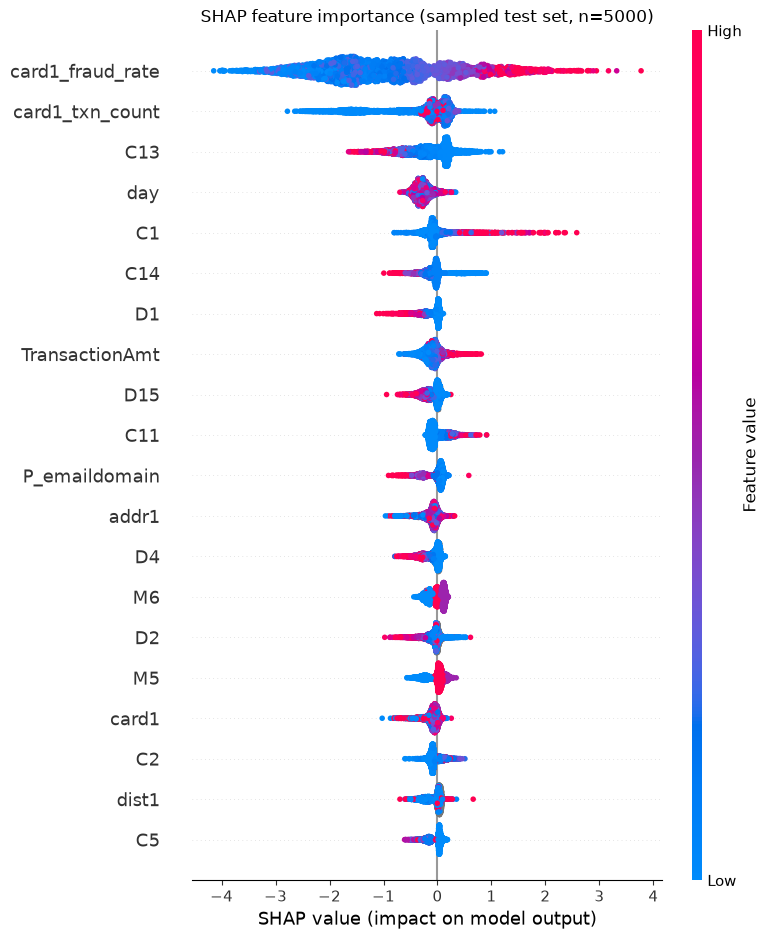

Saved: ../models/shap_summary_plot.png


In [5]:
# Summary plot: top 20 features, with each transaction shown as a dot
# Color = feature value, x-position = SHAP impact on prediction
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title("SHAP feature importance (sampled test set, n=5000)")
plt.tight_layout()
plt.savefig(ARTIFACTS / "shap_summary_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {ARTIFACTS / 'shap_summary_plot.png'}")

In [6]:
# Find the highest-risk transaction in the sample
sample_proba = xgb_clf.predict_proba(X_sample)[:, 1]
top_fraud_idx = np.argmax(sample_proba * (y_sample.values == 1))

print(f"Selected fraud transaction: row {top_fraud_idx}")
print(f"  Predicted fraud probability: {sample_proba[top_fraud_idx]:.4f}")
print(f"  Actual label: {y_sample.iloc[top_fraud_idx]} (fraud)")

# Top 10 contributing features for this prediction
single_shap = shap_values[top_fraud_idx]
single_features = X_sample.iloc[top_fraud_idx]

contributions = pd.DataFrame({
    "feature": X_sample.columns,
    "value": single_features.values,
    "shap_contribution": single_shap,
}).assign(abs_contrib=lambda d: d["shap_contribution"].abs())
contributions = contributions.sort_values("abs_contrib", ascending=False).drop(columns="abs_contrib")

print("\nTop 10 contributing features:")
print(contributions.head(10).to_string(index=False))

print(f"\nSum of all SHAP values: {single_shap.sum():.4f}")
print(f"Plus baseline (log-odds): {explainer.expected_value:.4f}")
print(f"= Final log-odds:          {single_shap.sum() + explainer.expected_value:.4f}")
print(f"Converted to probability:  {1/(1+np.exp(-(single_shap.sum() + explainer.expected_value))):.4f}")
print(f"Model's actual prediction: {sample_proba[top_fraud_idx]:.4f}")

Selected fraud transaction: row 2476
  Predicted fraud probability: 0.9999
  Actual label: 1 (fraud)

Top 10 contributing features:
feature  value  shap_contribution
   V156    7.0           1.726184
     C1    7.0           1.242285
   V258    4.0           0.992496
    C13    0.0           0.948261
    C11    4.0           0.547533
    C14    0.0           0.546561
   V256    4.0           0.490976
   V149    6.0           0.400299
   V250    2.0           0.376992
    day  175.0          -0.370660

Sum of all SHAP values: 9.1787
Plus baseline (log-odds): 0.1380
= Final log-odds:          9.3167
Converted to probability:  0.9999
Model's actual prediction: 0.9999


In [7]:
# The FastAPI service needs to compute SHAP on the fly for each incoming transaction
# We save the explainer object — it's reusable for any input

joblib.dump(explainer, ARTIFACTS / "shap_explainer.joblib")

# Also save the global feature importance for the dashboard
feature_importance.to_csv(ARTIFACTS / "global_feature_importance.csv", index=False)

# Verify size
explainer_size = (ARTIFACTS / "shap_explainer.joblib").stat().st_size / 1e6
print(f"Saved shap_explainer.joblib  ({explainer_size:.1f} MB)")
print(f"Saved global_feature_importance.csv")

Saved shap_explainer.joblib  (62.4 MB)
Saved global_feature_importance.csv


In [8]:
import time

# Time SHAP computation on single rows (this is what the API will do per request)
single_row_times = []
for i in range(50):
    start = time.perf_counter()
    _ = explainer.shap_values(X_sample.iloc[[i]])
    single_row_times.append((time.perf_counter() - start) * 1000)

import numpy as np
print(f"SHAP latency on single rows (n=50):")
print(f"  Mean: {np.mean(single_row_times):.2f} ms")
print(f"  p50:  {np.percentile(single_row_times, 50):.2f} ms")
print(f"  p95:  {np.percentile(single_row_times, 95):.2f} ms")
print(f"  p99:  {np.percentile(single_row_times, 99):.2f} ms")
print(f"\nArchitecture-doc target: p95 < 100ms — {'✓ MET' if np.percentile(single_row_times, 95) < 100 else '✗ MISSED'}")

SHAP latency on single rows (n=50):
  Mean: 12.63 ms
  p50:  12.51 ms
  p95:  13.26 ms
  p99:  14.86 ms

Architecture-doc target: p95 < 100ms — ✓ MET
